In [1]:
#import essensial libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#read data
df=pd.read_csv('retail_data.csv')
df.head()

,Order_ID,Order_Date,Region,Category,Product,Quantity,Price,Revenue,Customer_Type
0,1001,2024-01-01,East,Clothing,Shirt,5,766,3830,Premium
1,1002,2024-01-02,South,Clothing,Shirt,5,430,2150,New
2,1003,2024-01-03,West,Furniture,Bed,4,7311,29244,Regular
3,1004,2024-01-04,South,Furniture,Chair,4,27658,110632,Premium
4,1005,2024-01-05,East,Furniture,Table,3,3267,9801,New


In [3]:
df.shape

(1200, 9)

In [4]:
rows,columns=df.shape
print('No of Rows=',rows)
print('No of Columns=',columns)

No of Rows= 1200
No of Columns= 9


In [5]:
#use of info functiom
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Order_ID       1200 non-null   int64 
 1   Order_Date     1200 non-null   object
 2   Region         1200 non-null   object
 3   Category       1200 non-null   object
 4   Product        1200 non-null   object
 5   Quantity       1200 non-null   int64 
 6   Price          1200 non-null   int64 
 7   Revenue        1200 non-null   int64 
 8   Customer_Type  1200 non-null   object
dtypes: int64(4), object(5)
memory usage: 84.5+ KB


In [6]:
#use of describe function
df.describe()

,Order_ID,Quantity,Price,Revenue
count,1200.000000,1200.000000,1200.000000,1200.000000
mean,1600.500000,2.995000,19118.180833,57254.708333
std,346.554469,1.429456,16540.229901,60431.870473
min,1001.000000,1.000000,301.000000,312.000000
25%,1300.750000,2.000000,3815.000000,10760.500000
50%,1600.500000,3.000000,14964.000000,33304.500000
75%,1900.250000,4.000000,31664.000000,85656.000000
max,2200.000000,5.000000,59539.000000,297410.000000


In [7]:
#KPIs
Total_revenue=df['Revenue'].sum()
print('Total Revenue=',Total_revenue)

Total Revenue= 68705650


In [8]:
#total orders
total_orders=df['Order_ID'].nunique()
print('Total Numbers of column=',total_orders)

Total Numbers of column= 1200


In [9]:
#average order value
avg_order_value=Total_revenue/total_orders
print('Average Order Value= ',avg_order_value.round(2))

Average Order Value=  57254.71


In [10]:
#name of region
regions=df['Region'].unique()
print(regions)

['East' 'South' 'West' 'North']


In [11]:
#names of categories
categories=df['Category'].unique()
print(categories)

['Clothing' 'Furniture' 'Electronics']


In [12]:
#find revenue by region
revenue_by_region=df.groupby('Region')['Revenue'].sum()
print(revenue_by_region)


Region
East     20216995
North    17500531
South    14856901
West     16131223
Name: Revenue, dtype: int64


In [13]:
#find revenue by categories
revenue_by_categories=df.groupby('Category')['Revenue'].sum()
print(revenue_by_categories)

Category
Clothing        3067357
Electronics    38471262
Furniture      27167031
Name: Revenue, dtype: int64


In [23]:
#find sale by categories
sales_by_categories=df.groupby('Category')['Quantity'].sum()
print(sales_by_categories)

Category
Clothing       1123
Electronics    1187
Furniture      1284
Name: Quantity, dtype: int64


In [15]:
#monthly sale trend
df['Order_Data']=pd.to_datetime(df['Order_Date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order_ID       1200 non-null   int64         
 1   Order_Date     1200 non-null   datetime64[ns]
 2   Region         1200 non-null   object        
 3   Category       1200 non-null   object        
 4   Product        1200 non-null   object        
 5   Quantity       1200 non-null   int64         
 6   Price          1200 non-null   int64         
 7   Revenue        1200 non-null   int64         
 8   Customer_Type  1200 non-null   object        
dtypes: datetime64[ns](1), int64(4), object(4)
memory usage: 84.5+ KB


In [16]:
df['Month']=df['Order_Date'].dt.to_period('M')
df.head(2)

,Order_ID,Order_Date,Region,Category,Product,Quantity,Price,Revenue,Customer_Type,Month
0,1001,2024-01-01,East,Clothing,Shirt,5,766,3830,Premium,2024-01
1,1002,2024-01-02,South,Clothing,Shirt,5,430,2150,New,2024-01


In [17]:
#montly sales
monthly_sales=df.groupby('Month')['Revenue'].sum()
print(monthly_sales)

Month
2024-01    1455587
2024-02    1730641
2024-03    2186488
2024-04    1241103
2024-05    1362302
2024-06    1565375
2024-07    1953087
2024-08    1676156
2024-09    1746614
2024-10    1848488
2024-11    1758142
2024-12    1823162
2025-01    1667306
2025-02    1345225
2025-03    1999268
2025-04    1421025
2025-05    2150238
2025-06    1652101
2025-07    1306176
2025-08    1718743
2025-09    1999211
2025-10    1965151
2025-11    1752750
2025-12    1359771
2026-01    1880498
2026-02    1337441
2026-03    2401329
2026-04    1962315
2026-05    1368605
2026-06    1586649
2026-07    1672009
2026-08    1511517
2026-09    1570624
2026-10    1056171
2026-11    2893861
2026-12    2237799
2027-01    1847042
2027-02    1561170
2027-03    2345631
2027-04     788879
Freq: M, Name: Revenue, dtype: int64


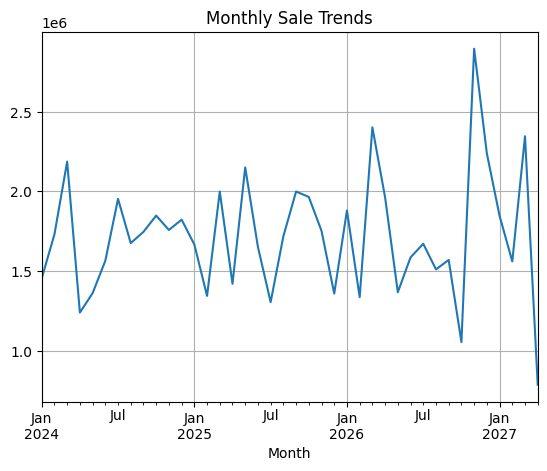

In [20]:
#visualization of data
monthly_sales.plot(kind='line')
plt.title('Monthly Sale Trends')
plt.grid()
plt.show()